In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
DATA_PATH = Path("../data/raw/flights_2025_01.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)

df.shape

(539747, 26)

In [3]:
completed = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARR_DEL15"].notna())
    ].copy()

completed.shape

(522269, 26)

In [4]:
completed["ROUTE"] = completed["ORIGIN"] + "_" + completed["DEST"]

completed[["ORIGIN", "DEST", "ROUTE"]].head()

,ORIGIN,DEST,ROUTE
0,SFO,JFK,SFO_JFK
1,JFK,SFO,JFK_SFO
2,SAT,CLT,SAT_CLT
3,JFK,LAX,JFK_LAX
4,BOS,LAX,BOS_LAX


In [5]:
target = "ARR_DEL15"

numeric_features = [
    "MONTH",
    "DAY_OF_WEEK",
    "DAY_OF_MONTH",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DISTANCE",
    "DISTANCE_GROUP"
]

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]

features = numeric_features + categorical_features

X = completed[features]
y = completed[target].astype(int)

X.head()

,MONTH,DAY_OF_WEEK,DAY_OF_MONTH,CRS_DEP_TIME,CRS_ARR_TIME,DISTANCE,DISTANCE_GROUP,OP_UNIQUE_CARRIER,ORIGIN,DEST,DEP_TIME_BLK,ARR_TIME_BLK
0,1,3,1,1030,1912,2586.0,11,AA,SFO,JFK,1000-1059,1900-1959
1,1,3,1,600,940,2586.0,11,AA,JFK,SFO,0600-0659,0900-0959
2,1,3,1,819,1206,1095.0,5,AA,SAT,CLT,0800-0859,1200-1259
3,1,3,1,2100,29,2475.0,10,AA,JFK,LAX,2100-2159,0001-0559
4,1,3,1,801,1140,2611.0,11,AA,BOS,LAX,0800-0859,1100-1159


In [6]:
y.value_counts(normalize=True) * 100

ARR_DEL15
0    81.210832
1    18.789168
Name: proportion, dtype: float64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((417815, 12), (104454, 12))

In [8]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [9]:
dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

dummy_model.fit(X_train, y_train)

dummy_preds = dummy_model.predict(X_test)

In [10]:
print("Dummy Model Results")
print("Accuracy:", accuracy_score(y_test, dummy_preds))
print("Precision:", precision_score(y_test, dummy_preds, zero_division=0))
print("Recall:", recall_score(y_test, dummy_preds, zero_division=0))
print("F1:", f1_score(y_test, dummy_preds, zero_division=0))

print()
print(classification_report(y_test, dummy_preds, zero_division=0))

Dummy Model Results
Accuracy: 0.8121086794186915
Precision: 0.0
Recall: 0.0
F1: 0.0

              precision    recall  f1-score   support

           0       0.81      1.00      0.90     84828
           1       0.00      0.00      0.00     19626

    accuracy                           0.81    104454
   macro avg       0.41      0.50      0.45    104454
weighted avg       0.66      0.81      0.73    104454



In [11]:
log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
        ))
    ]
)

log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['MONTH','DAY_OF_WEEK','DAY_OF_MONTH',...,'DEST','DEP_TIME_BLK', 'ARR_TIME_BLK']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough

In [12]:
log_reg_preds = log_reg_model.predict(X_test)
log_reg_probs = log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_reg_preds))
print("Precision:", precision_score(y_test, log_reg_preds))
print("Recall:", recall_score(y_test, log_reg_preds))
print("F1:", f1_score(y_test, log_reg_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_reg_probs))

print()
print(classification_report(y_test, log_reg_preds))

Logistic Regression Results
Accuracy: 0.602523598904781
Precision: 0.26160815402038506
Recall: 0.6120452461021094
F1: 0.36654359036953404
ROC-AUC: 0.6477769936997598

              precision    recall  f1-score   support

           0       0.87      0.60      0.71     84828
           1       0.26      0.61      0.37     19626

    accuracy                           0.60    104454
   macro avg       0.57      0.61      0.54    104454
weighted avg       0.76      0.60      0.65    104454



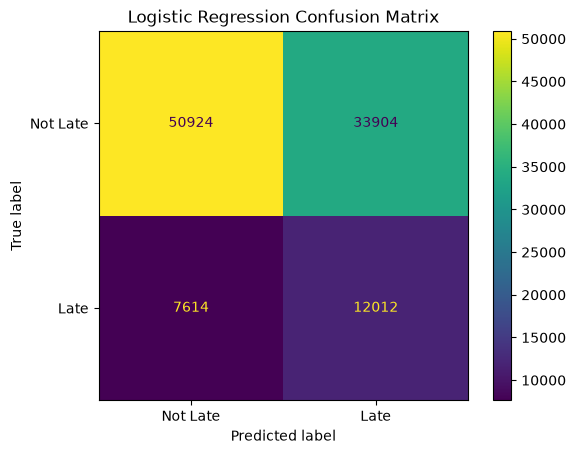

In [13]:
cm = confusion_matrix(y_test, log_reg_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [14]:
results = pd.DataFrame([
    {
        "model": "Dummy Most Frequent",
        "accuracy": accuracy_score(y_test, dummy_preds),
        "precision": precision_score(y_test, dummy_preds, zero_division=0),
        "recall": recall_score(y_test, dummy_preds, zero_division=0),
        "f1": f1_score(y_test, dummy_preds, zero_division=0),
        "roc_auc": np.nan
    },
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, log_reg_preds),
        "precision": precision_score(y_test, log_reg_preds),
        "recall": recall_score(y_test, log_reg_preds),
        "f1": f1_score(y_test, log_reg_preds),
        "roc_auc": roc_auc_score(y_test, log_reg_probs)
    }
])

results

,model,accuracy,precision,recall,f1,roc_auc
0,Dummy Most Frequent,0.812109,0.000000,0.000000,0.000000,NaN
1,Logistic Regression,0.602524,0.261608,0.612045,0.366544,0.647777


In [15]:
Path("../visuals").mkdir(exist_ok=True)

results.to_csv("../visuals/baseline_model_results.csv", index=False)

results

,model,accuracy,precision,recall,f1,roc_auc
0,Dummy Most Frequent,0.812109,0.000000,0.000000,0.000000,NaN
1,Logistic Regression,0.602524,0.261608,0.612045,0.366544,0.647777


The dummy model achieved high accuracy because most flights were not delayed, but it failed to identify any delayed flights. Its recall and F1-score for delayed flights were both 0.

The logistic regression model had lower accuracy, but it detected delayed flights much better. It reached about 61% recall for delayed flights, meaning it found over half of the actual delayed flights. However, precision was only about 26%, meaning many flights predicted as delayed were actually on time.

This shows that accuracy alone is misleading for this imbalanced dataset. Recall, precision, F1-score, and ROC-AUC are more useful for evaluating delay prediction.

In [16]:
log_reg_plain_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000
        ))
    ]
)

log_reg_plain_model.fit(X_train, y_train)

plain_preds = log_reg_plain_model.predict(X_test)
plain_probs = log_reg_plain_model.predict_proba(X_test)[:, 1]

print("Plain Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, plain_preds))
print("Precision:", precision_score(y_test, plain_preds, zero_division=0))
print("Recall:", recall_score(y_test, plain_preds, zero_division=0))
print("F1:", f1_score(y_test, plain_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, plain_probs))

print()
print(classification_report(y_test, plain_preds, zero_division=0))

Plain Logistic Regression Results
Accuracy: 0.811984222720049
Precision: 0.448
Recall: 0.002853357790685825
F1: 0.005670598957014834
ROC-AUC: 0.6483023504786838

              precision    recall  f1-score   support

           0       0.81      1.00      0.90     84828
           1       0.45      0.00      0.01     19626

    accuracy                           0.81    104454
   macro avg       0.63      0.50      0.45    104454
weighted avg       0.74      0.81      0.73    104454



In [17]:
results = pd.DataFrame([
    {
        "model": "Dummy Most Frequent",
        "accuracy": accuracy_score(y_test, dummy_preds),
        "precision": precision_score(y_test, dummy_preds, zero_division=0),
        "recall": recall_score(y_test, dummy_preds, zero_division=0),
        "f1": f1_score(y_test, dummy_preds, zero_division=0),
        "roc_auc": np.nan
    },
    {
        "model": "Logistic Regression Balanced",
        "accuracy": accuracy_score(y_test, log_reg_preds),
        "precision": precision_score(y_test, log_reg_preds),
        "recall": recall_score(y_test, log_reg_preds),
        "f1": f1_score(y_test, log_reg_preds),
        "roc_auc": roc_auc_score(y_test, log_reg_probs)
    },
    {
        "model": "Logistic Regression Plain",
        "accuracy": accuracy_score(y_test, plain_preds),
        "precision": precision_score(y_test, plain_preds, zero_division=0),
        "recall": recall_score(y_test, plain_preds, zero_division=0),
        "f1": f1_score(y_test, plain_preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, plain_probs)
    }
])

results

,model,accuracy,precision,recall,f1,roc_auc
0,Dummy Most Frequent,0.812109,0.000000,0.000000,0.000000,NaN
1,Logistic Regression Balanced,0.602524,0.261608,0.612045,0.366544,0.647777
2,Logistic Regression Plain,0.811984,0.448000,0.002853,0.005671,0.648302


The plain logistic regression model achieved high accuracy, but it almost never predicted flights as delayed. Its recall for delayed flights was only about 0.29%, meaning it missed nearly all actual delays.

The balanced logistic regression model had lower accuracy, but it identified delayed flights much more effectively, reaching about 61% recall. This shows that class imbalance can make accuracy misleading. For this project, recall and F1-score are more meaningful than accuracy because the goal is to detect delayed flights, not simply predict the majority class.

In [18]:
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    threshold_preds = (log_reg_probs >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, threshold_preds),
        "precision": precision_score(y_test, threshold_preds, zero_division=0),
        "recall": recall_score(y_test, threshold_preds, zero_division=0),
        "f1": f1_score(y_test, threshold_preds, zero_division=0)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,accuracy,precision,recall,f1
0,0.25,0.218718,0.192165,0.985733,0.321629
1,0.30,0.263915,0.198889,0.963569,0.329721
2,0.35,0.332012,0.209125,0.918526,0.340685
3,0.40,0.418979,0.223400,0.844951,0.353371
4,0.45,0.511594,0.240209,0.739427,0.362619
5,0.50,0.602524,0.261608,0.612045,0.366544
6,0.55,0.680405,0.286931,0.471976,0.356894
7,0.60,0.741111,0.316997,0.327270,0.322052


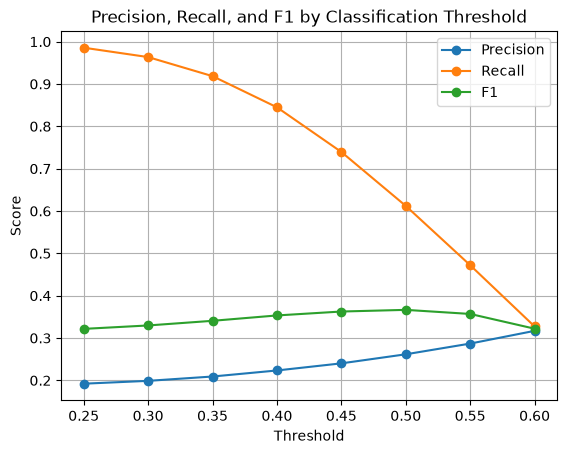

In [19]:
plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], marker='o', label="Precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], marker='o', label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1"], marker='o', label="F1")

plt.title("Precision, Recall, and F1 by Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

The threshold tuning results showed a clear precision-recall tradeoff. Lower thresholds increased recall but caused many false positives, while higher thresholds improved precision and accuracy but missed more delayed flights.

Among the tested thresholds, 0.50 produced the best F1-score for the balanced logistic regression model. This means the default threshold currently gives the best balance between precision and recall for this model.